In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
sys.path.append('../../../src')
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, FilterEnum, ErrorEnum, NoiseTypeEnum
from scipy.optimize import minimize
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from noise_optimizers import CKF_NoiseOptimizer
from numpy.linalg import norm

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
kitti_root_dir = '../../../data'
vo_root_dir = '../../../vo_estimates'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                vo_root_dir=vo_root_dir,
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/ckf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/ckf'

In [4]:
ckf_optimizer = CKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
ckf_optimizer.compare(load_exported=True)

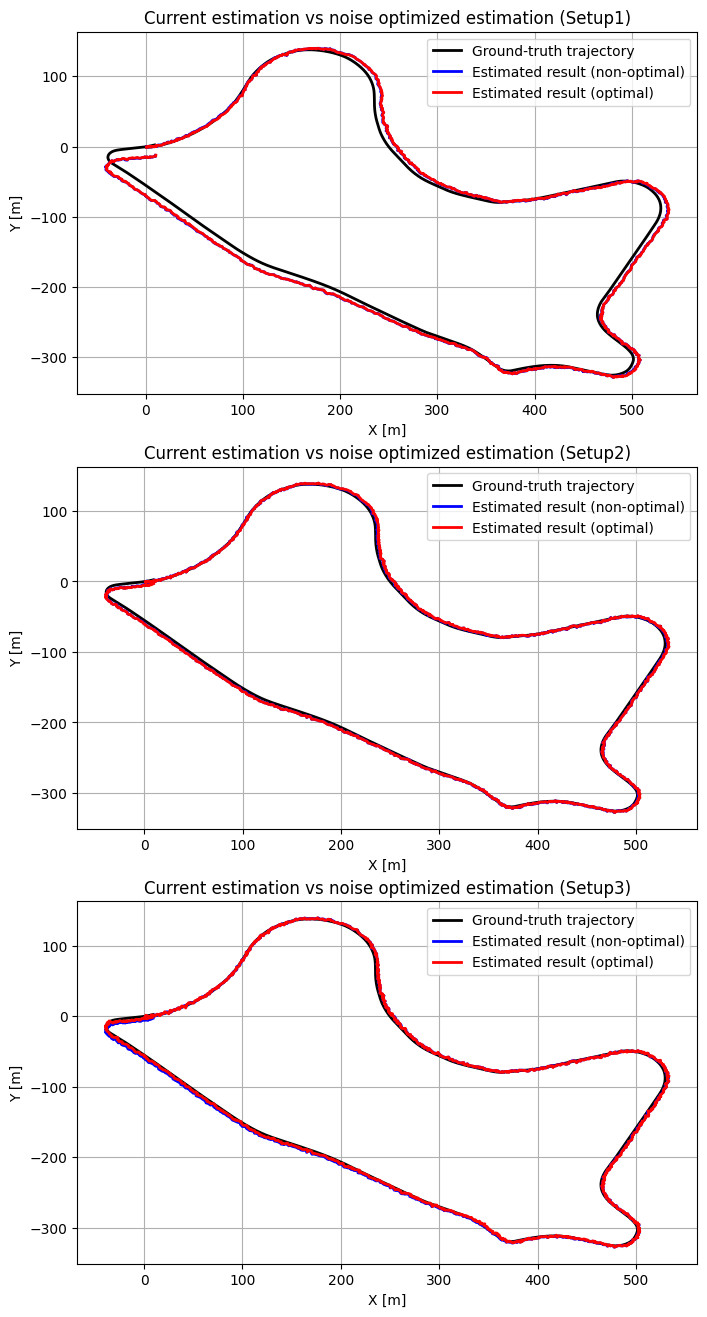

In [6]:
ckf_optimizer.visualize_results()

In [7]:
ckf_optimizer.error_df

Setups        Setup1(IMU+VO)                Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE     MAX                MAE   RMSE    MAX   
Non-optimized          3.887  5.469  16.386              1.461  1.976  6.407   
Optimized              4.000  5.573  15.873              1.579  2.133  6.648   
∆                      0.113  0.104  -0.513              0.118  0.157  0.241   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       1.546  2.108  6.591  
Optimized           1.455  1.781  4.876  
∆                  -0.091 -0.327 -1.715

## Conclusion

In this notebook, the noise optimization technique, Nelder-Mead algorithm, is applied to the Cubature Kalman Filter.

The results show that the noise optimization was not working correctly, where the optimizer never converged in the setup 1, resulting in the experiencing large error in the trajectory. In terms of the setup2, although the optimizer converges, the performance is worse than the current implementation.

However, a performance improvement was observed in the setup 3 by decreasing all the given metrices indicating that the noise vectors, including process noise and measuremnt noise for VO and GPS, are optimized by the given algorithm.